In [38]:
#1 import libraries
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Dataset and ML tools
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

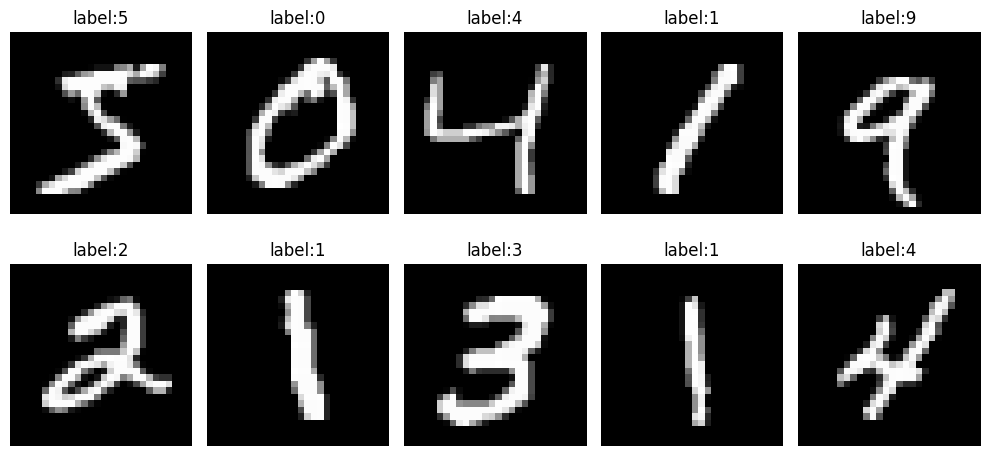

In [39]:
#2 load dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=True)

X=mnist.data
y=mnist.target

plt.figure(figsize=(10,5))
for i in range(10):
  image=X.iloc[i].values.reshape(28,28)
  label=y.iloc[i]

  plt.subplot(2,5,i+1)
  plt.imshow(image, cmap='gray')
  plt.title(f'label:{label}')
  plt.axis('off')

plt.tight_layout()
plt.show()

In [40]:
#3 preprocessing (normalization)

X=X/255.0
y=y.astype(int)


In [41]:
#4 train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [42]:
#5 model 1
log_reg=LogisticRegression(max_iter=1000,solver='lbfgs',multi_class='multinomial',n_jobs=-1)
log_reg.fit(X_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=-1)

In [43]:
y_pred_log = log_reg.predict(X_test)

In [44]:
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)
print("Accuracy percentage:", log_accuracy * 100)
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9215
Accuracy percentage: 92.15
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.95      0.97      0.96      1575
           2       0.93      0.90      0.91      1398
           3       0.90      0.89      0.90      1428
           4       0.93      0.92      0.93      1365
           5       0.88      0.87      0.88      1263
           6       0.94      0.96      0.95      1375
           7       0.93      0.94      0.94      1459
           8       0.89      0.88      0.89      1365
           9       0.90      0.89      0.89      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



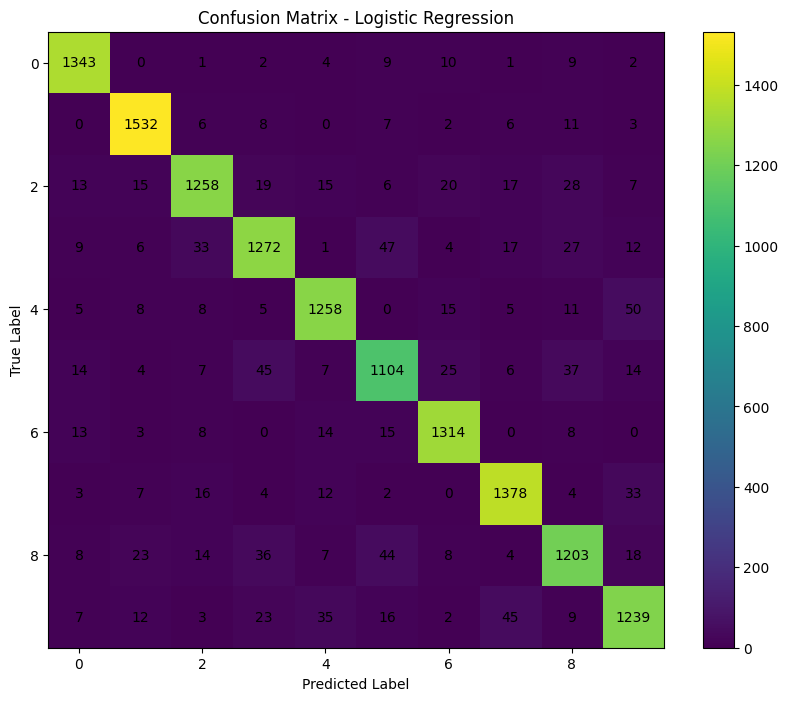

In [45]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(10, 8))
plt.imshow(cm_log)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm_log[i, j], ha="center", va="center")

plt.show()

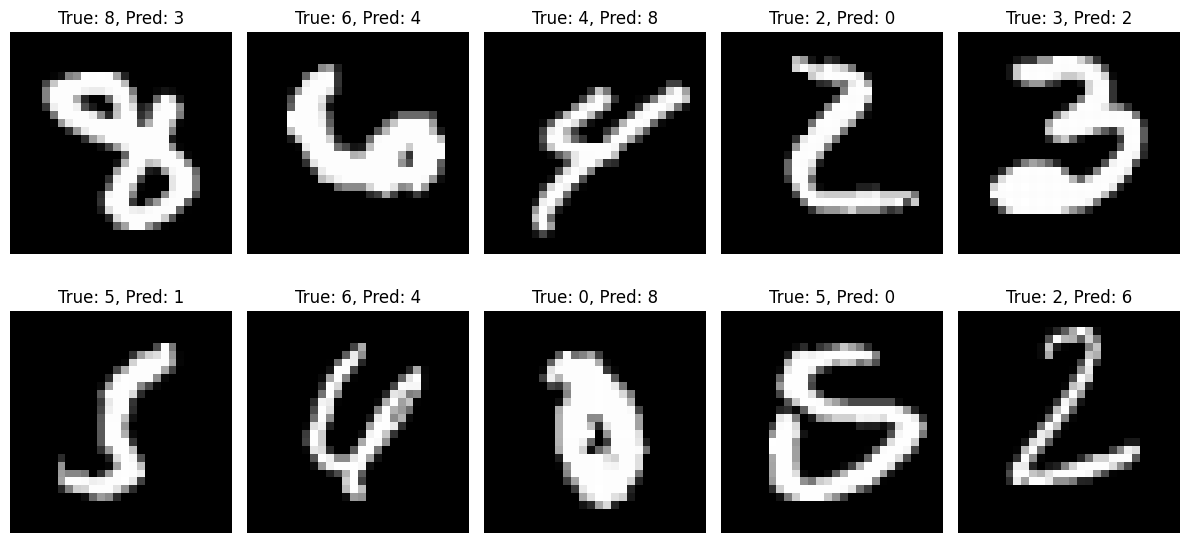

In [46]:
wrong_indices = np.where(y_pred_log != y_test.to_numpy())[0]

plt.figure(figsize=(12, 6))

for i, wrong_index in enumerate(wrong_indices[:10]):
    image = X_test.iloc[wrong_index].values.reshape(28, 28)
    true_label = y_test.iloc[wrong_index]
    predicted_label = y_pred_log[wrong_index]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {true_label}, Pred: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [47]:
# 6 model 2
X_train_knn = X_train[:10000]
y_train_knn = y_train[:10000]

X_test_knn = X_test[:2000]
y_test_knn = y_test[:2000]

In [48]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_knn, y_train_knn)

KNeighborsClassifier(n_neighbors=3)

In [49]:
knn_accuracy = accuracy_score(y_test_knn, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print("Accuracy percentage:", knn_accuracy * 100)
print(classification_report(y_test_knn, y_pred_knn))

KNN Accuracy: 0.949
Accuracy percentage: 94.89999999999999
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       216
           1       0.89      0.99      0.94       221
           2       0.97      0.92      0.94       185
           3       0.96      0.97      0.96       207
           4       0.98      0.94      0.96       195
           5       0.96      0.94      0.95       190
           6       0.96      0.98      0.97       207
           7       0.95      0.93      0.94       214
           8       0.99      0.89      0.94       174
           9       0.91      0.93      0.92       191

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



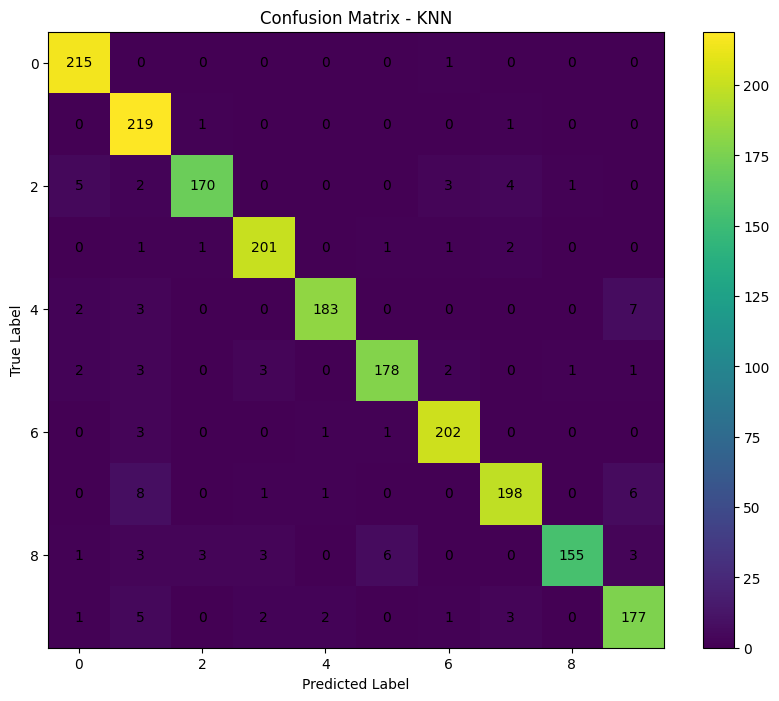

In [50]:
cm_knn = confusion_matrix(y_test_knn, y_pred_knn)

plt.figure(figsize=(10, 8))
plt.imshow(cm_knn)
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm_knn[i, j], ha="center", va="center")

plt.show()


In [51]:
#Test different values of K
k_accuracies = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_knn, y_train_knn)

    y_pred = knn_model.predict(X_test_knn)
    acc = accuracy_score(y_test_knn, y_pred)

    k_accuracies.append(acc)
    print(f"K = {k}, Accuracy = {acc}")

K = 1, Accuracy = 0.956
K = 3, Accuracy = 0.949
K = 5, Accuracy = 0.948
K = 7, Accuracy = 0.9405


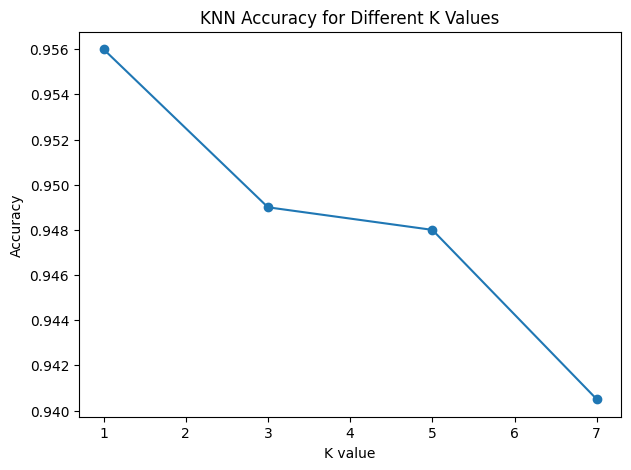

In [52]:
plt.figure(figsize=(7, 5))
plt.plot(k_values, k_accuracies, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.show()